In [1]:
import scanpy as sc

In [3]:
sc.__version__

'1.10.1'

# niche GO pattern

In [1]:
import numpy as np
import pandas as pd
import json
import os
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap
import itertools
import seaborn as sns
from collections import Counter
import glob
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/niche/GWall/Lateral_Horn_spDEG_GO.txt',sep='\t')
df['-log10FDR'] = -np.log10(df['Adjusted.P.value'])
df = df.sort_values('-log10FDR',ascending=False)
df = df[:5]

Text(0.5, 0, '-log10FDR')

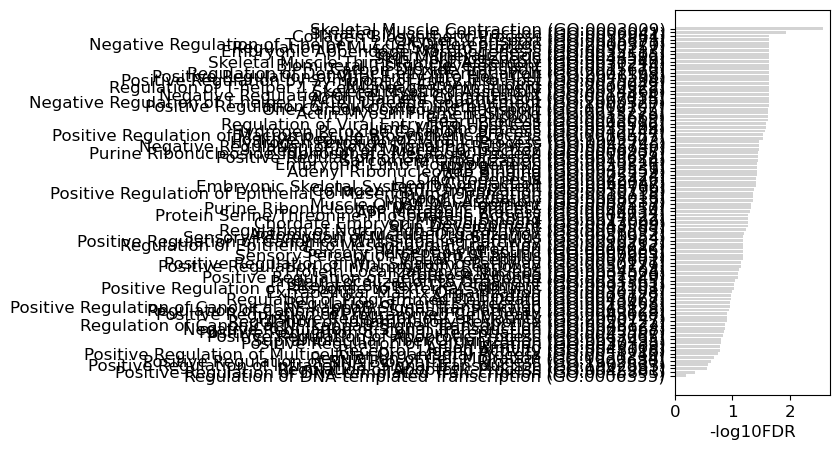

In [34]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.size']='12'
fig, ax = plt.subplots(figsize=(2,5))

terms = df.Term.values
terms = terms[::-1]
plt.barh(terms,df['-log10FDR'][::-1],color='lightgray')
plt.xlabel('-log10FDR')

In [26]:
#df = df[df.Term != 'Neuron Development (GO:0048666)']

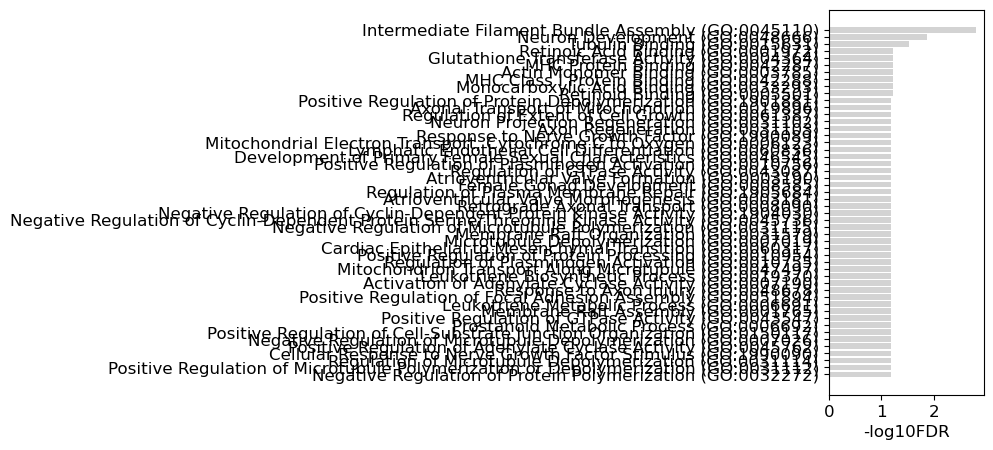

In [28]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.size']='12'
fig, ax = plt.subplots(figsize=(2,5))

terms = df.Term.values
terms = terms[::-1]
plt.barh(terms,df['-log10FDR'][::-1],color='lightgray')
plt.xlabel('-log10FDR')
plt.savefig('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/niche/GWall/Lateral_Horn_spDEG_GO.pdf',bbox_inches='tight',dpi=300)

In [19]:
import pandas as pd
import numpy as np
import os
import re

# 定义组别顺序
groups_order = [
    "Dorsal_Horn",
    "Intermediate_Gray",
    "Ventral_Horn",
    "Early_Horn/Lateral_Horn",
    "MN_Horn",
    "Early_White_Matter",
    "White_Matter",
    "VZ",
    "Meninge",
    "Cavity"
]

# 结果目录
result_dir = "/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/niche/GWall/"

# 初始化结果DataFrame
combined_results = pd.DataFrame()

# 循环处理每个组
for group in groups_order:
    # 构建文件名（处理特殊字符）
    safe_group = group.replace("/", "_")
    file_path = os.path.join(result_dir, f"{safe_group}_spDEG_GO.txt")
    
    # 检查文件是否存在
    if not os.path.exists(file_path):
        print(f"文件不存在: {file_path}")
        continue
    
    # 读取文件
    try:
        df = pd.read_csv(file_path, sep='\t')
        
        # 计算-log10(FDR)并排序
        df['-log10FDR'] = -np.log10(df['Adjusted.P.value'])
        df = df.sort_values('-log10FDR', ascending=False)
        
        # 取前5个最显著结果
        top5 = df.head(2).copy()
        
        # 添加组别信息
        top5['Group'] = group
        
        # 添加到合并结果
        combined_results = pd.concat([combined_results, top5], ignore_index=True)
        
    except Exception as e:
        print(f"处理 {group} 时出错: {str(e)}")
        continue

# 按指定组别顺序排序
combined_results['Group'] = pd.Categorical(
    combined_results['Group'], 
    categories=groups_order, 
    ordered=True
)
combined_results = combined_results.sort_values(['Group', '-log10FDR'], ascending=[True, False])

combined_results['GO'] = combined_results.apply(lambda row: 
    f"{re.sub(r'\(GO:\d+\)', '', row['Term']).strip()} ({'BP' if 'Biological' in row['Name'] else 'MF'})", 
    axis=1)

In [20]:
combined_results

,Name,Term,Overlap,P.value,Adjusted.P.value,Old.P.value,Old.Adjusted.P.value,Odds.Ratio,Combined.Score,Genes,-log10FDR,Group,GO
0,GO Biological Process 2025,Nervous System Development (GO:0007399),17/480,2.334091e-10,2.070339e-07,0,0,8.598428,190.697907,KIRREL3;ROBO2;RBFOX1;NLGN1;RBFOX3;DSCAM;NRG1;E...,6.683959,Dorsal_Horn,Nervous System Development (BP)
1,GO Biological Process 2025,Chemical Synaptic Transmission (GO:0007268),11/260,7.402829e-08,3.283155e-05,0,0,9.754118,160.151086,GRM3;PTPRN2;SST;NPY;GAD1;AKAP9;PENK;CACNA1A;AM...,4.483709,Dorsal_Horn,Chemical Synaptic Transmission (BP)
2,GO Biological Process 2025,Modulation of Chemical Synaptic Transmission (...,8/117,1.280381e-07,5.095915e-05,0,0,15.788592,250.579766,RIMS1;PPP3CA;GRID2;NRG3;CASK;DLGAP1;LRRC4C;GRIA4,4.292778,Intermediate_Gray,Modulation of Chemical Synaptic Transmission (BP)
3,GO Biological Process 2025,Regulation of Trans-Synaptic Signaling (GO:009...,6/47,1.221200e-07,5.095915e-05,0,0,30.916969,492.144413,PPP3CA;GRID2;NRG3;DLGAP1;LRRC4C;GRIA4,4.292778,Intermediate_Gray,Regulation of Trans-Synaptic Signaling (BP)
4,GO Biological Process 2025,Cellular Respiration (GO:0045333),7/85,2.266063e-07,1.207812e-04,0,0,19.127929,292.658305,COX8A;NDUFA8;NDUFB11;NDUFA3;NDUFS4;UQCRFS1;COX5B,3.918001,Ventral_Horn,Cellular Respiration (BP)
5,GO Biological Process 2025,Aerobic Electron Transport Chain (GO:0019646),6/64,7.962604e-07,1.552293e-04,0,0,21.836390,306.655845,COX8A;NDUFA8;NDUFA3;NDUFS4;UQCRFS1;COX5B,3.809026,Ventral_Horn,Aerobic Electron Transport Chain (BP)
6,GO Biological Process 2025,Intermediate Filament Bundle Assembly (GO:0045...,2/7,9.535772e-06,1.544795e-03,0,0,666.033333,7699.651952,NEFL;NEFM,2.811129,Early_Horn/Lateral_Horn,Intermediate Filament Bundle Assembly (BP)
7,GO Biological Process 2025,Neuron Development (GO:0048666),3/159,1.682794e-04,1.363063e-02,0,0,34.667832,301.259468,ADCYAP1;STMN2;PBX3,1.865484,Early_Horn/Lateral_Horn,Neuron Development (BP)
8,GO Biological Process 2025,Intermediate Filament Bundle Assembly (GO:0045...,3/7,3.481864e-08,1.027150e-05,0,0,832.291667,14293.038809,NEFL;NEFM;NEFH,4.988366,MN_Horn,Intermediate Filament Bundle Assembly (BP)
9,GO Molecular Function 2025,Tubulin Binding (GO:0015631),5/326,1.832089e-05,8.427611e-04,0,0,19.137461,208.741252,KIF5C;STMN2;NEFL;NEFM;NEFH,3.074296,MN_Horn,Tubulin Binding (MF)


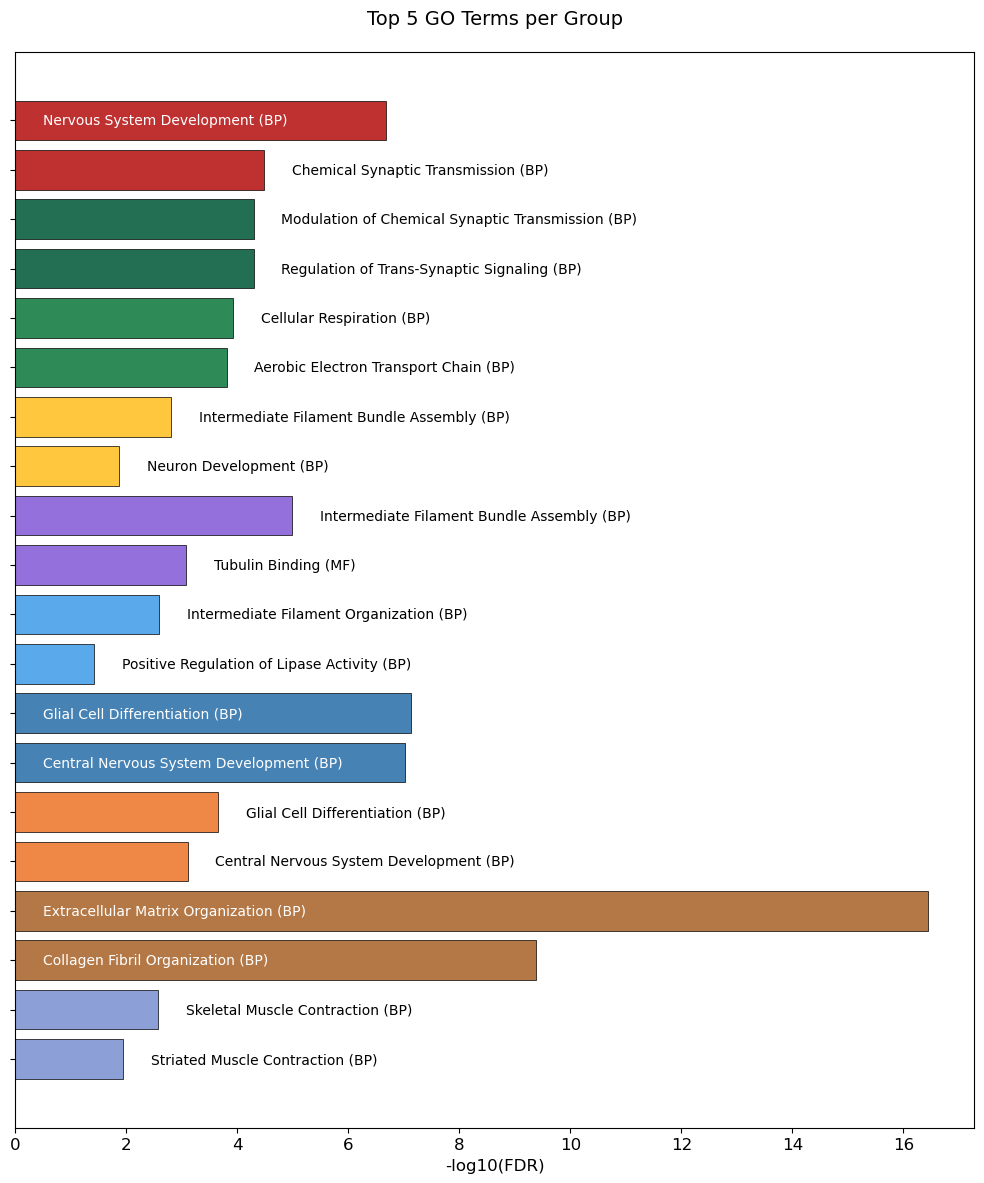

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# 设置图形参数
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.size'] = 12


# 创建图形
fig, ax = plt.subplots(figsize=(10, 12))

# 准备数据 - 反转顺序以便从上到下显示
GOs = combined_results['GO'].values[::-1]
log10fdr = combined_results['-log10FDR'].values[::-1]
groups = combined_results['Group'].values[::-1]

# 为不同组别设置不同颜色
group_colors = {
    'Dorsal_Horn': '#BF3131',
    'Intermediate_Gray': '#226f54',
    'Ventral_Horn': '#2E8B57',
    'Early_Horn/Lateral_Horn': '#FFC73D',
    'MN_Horn': '#9370DB',
    'Early_White_Matter': '#1988E3B7',
    'White_Matter': '#4682B4',
    'VZ': '#EF8746',
    'Meninge': '#b47846',
    'Cavity': '#8ca0d7'
}

# 创建柱状图
bars = ax.barh(range(len(GOs)), log10fdr, 
               color=[group_colors[g] for g in groups],
               edgecolor='black', linewidth=0.5)

# 在柱状图内部添加Term名称
for i, (GO, fdr, group) in enumerate(zip(GOs, log10fdr, groups)):
    # 根据柱状图宽度决定文本位置
    if fdr > 5:  # 如果柱子足够宽，文本放在柱子内部右侧
        ax.text(0.5, i, GO, ha='left', va='center', color='white', fontsize=10)
    else:  # 如果柱子太窄，文本放在柱子外部右侧
        ax.text(fdr + 0.5, i, GO, ha='left', va='center', color='black', fontsize=10)

# 添加组别图例
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, edgecolor='black', label=group) 
                   for group, color in group_colors.items()]
#ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')

# 设置y轴标签
ax.set_yticks(range(len(GOs)))
ax.set_yticklabels([])  # 不显示y轴标签，因为term已经在柱子内部

# 设置x轴标签
ax.set_xlabel('-log10(FDR)', fontsize=12)
ax.set_title('Top 5 GO Terms per Group', fontsize=14, pad=20)

# 调整布局
plt.tight_layout()
plt.savefig('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/niche/GWall/GO_Terms_Barplot.pdf', 
            bbox_inches='tight', dpi=300)

plt.show()

In [17]:
combined_results.to_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/niche/GWall/Combined_Top_GO_Results_with_GO_column.txt', 
                       sep='\t', index=False)

# spatial niche gene pattern

In [26]:
import scanpy as sc
import numpy as np
import pandas as pd

In [68]:
adata =  sc.read("/cluster2/huanglab/jiamao/Project/Tools/nichecompass-reproducibility/artifacts/stereo_seq_spinal_cord_gwall/results/single_sample/27052025_044245/stereo_seq_spinal_cord_gwall_analysis.h5ad")

In [69]:
# 提取batch为'gw12', 'gw16'的细胞研究功能
selected_batches = ['gw12', 'gw16']
adata = adata[adata.obs['batch'].isin(selected_batches), :]

# 排除mt
non_mt_genes = [gene for gene in adata.var_names if not gene.startswith('MT-')]
# 子集化adata对象
adata = adata[:, non_mt_genes].copy()

In [70]:
sc.tl.rank_genes_groups(adata, groupby='niche', method='wilcoxon')

In [71]:
marker_niche = sc.get.rank_genes_groups_df(adata, group=None, key = 'rank_genes_groups', log2fc_min =0.25, pval_cutoff=0.05)

In [105]:
top_genes_per_niche = (
    marker_niche
    .groupby('group')  # 按 niche 分组
    .apply(lambda x: x.nlargest(100, 'scores'))  # 按 scores 取前 100
    .reset_index(drop=True)
)

In [109]:
top_genes_ordered

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,Dorsal_Horn,STMN2,38.088661,2.421237,0.000000e+00,0.000000e+00
1,Dorsal_Horn,RBFOX1,26.027870,2.206044,2.395824e-149,9.572513e-146
2,Dorsal_Horn,TMSB10,23.479050,1.435169,6.677732e-122,1.778725e-118
3,Dorsal_Horn,SST,21.486166,2.430249,2.097293e-102,3.351894e-99
4,Dorsal_Horn,NPY,20.559904,3.920345,6.275639e-94,6.268579e-91
...,...,...,...,...,...,...
104,Cavity,HBA2,6.111376,0.281142,9.877597e-10,6.523296e-08
105,Cavity,TNNC2,5.305463,1.656631,1.123876e-07,5.282878e-06
106,Cavity,ACTA1,5.075452,1.765841,3.865756e-07,1.560164e-05
107,Cavity,LGALS1,3.793530,0.475125,1.485204e-04,3.066736e-03


In [111]:
niche_genes_dict = (
    top_genes_ordered
    .groupby('group')['names']  # 按 niche 分组，提取基因名
    .apply(list)                # 将每组基因转为列表
    .to_dict()                  # 转换为字典
)
niche_genes_dict

{'Dorsal_Horn': ['STMN2',
  'RBFOX1',
  'TMSB10',
  'SST',
  'NPY',
  'EBF3',
  'SOX4',
  'MALAT1',
  'EBF1',
  'GAP43',
  'ROBO2',
  'SRP14',
  'PTPRD',
  'SPOCK1',
  'HOXB7',
  'FAU',
  'KCNIP4',
  'PPP3CA',
  'HMGB1',
  'TENM3',
  'OLFM1',
  'NEGR1',
  'RPL18',
  'GALNTL6',
  'RPS5',
  'KIRREL3',
  'RPS15',
  'NBEA',
  'CADM2',
  'FGF14',
  'DLGAP1',
  'CELF2',
  'CBX1',
  'HOXB5',
  'PET100',
  'RPL18A',
  'NLGN1',
  'LSAMP',
  'C12orf57',
  'ID2',
  'HDGFL3',
  'EDF1',
  'SSTR2',
  'DPP10',
  'FTX',
  'CCK',
  'APC2',
  'MZT2B',
  'LSM7',
  'AMPH',
  'RPS7',
  'ZIC1',
  'FNBP1L',
  'LINC00632',
  'ATP6V1G1',
  'COMMD6',
  'AKAP9',
  'RNASEK',
  'NDUFB11',
  'ANKRD12',
  'COX20',
  'NRG3',
  'ETFB',
  'AUTS2',
  'TOMM7',
  'ERBB4',
  'NDUFA5',
  'FAM155A',
  'CACNA1A',
  'PPP1R1A',
  'LIN7C',
  'APLP1',
  'TRIR',
  'PTPRN2',
  'LHX1',
  'NRXN3',
  'RPL30',
  'CDH13',
  'ADCY1',
  'NDUFB8',
  'ZFAND6',
  'CACNA2D1',
  'SNRPD2',
  'RPS16',
  'DUSP8',
  'PENK',
  'CCDC144NL-AS1',
  'C

2025-07-25 12:45:07 - INFO - maxp pruned
2025-07-25 12:45:07 - INFO - cmap pruned
2025-07-25 12:45:07 - INFO - kern dropped
2025-07-25 12:45:07 - INFO - post pruned
2025-07-25 12:45:07 - INFO - FFTM dropped
2025-07-25 12:45:07 - INFO - GPOS pruned
2025-07-25 12:45:07 - INFO - GSUB pruned
2025-07-25 12:45:07 - INFO - glyf pruned
2025-07-25 12:45:07 - INFO - Added gid0 to subset
2025-07-25 12:45:07 - INFO - Added first four glyphs to subset
2025-07-25 12:45:07 - INFO - Closing glyph list over 'GSUB': 60 glyphs before
2025-07-25 12:45:07 - INFO - Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'c', 'd', 'e', 'eight', 'f', 'five', 'four', 'g', 'h', 'i', 'l', 'm', 'minus', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'r', 's', 'seven', 'six', 'slash', 'space', 't', 'three', 'two', 'underscore', 'v', 'x', 'y', 'zero']
2025-07-25 12:45:07 - INFO - Glyph IDs:   [0, 1, 2, 3, 18, 1

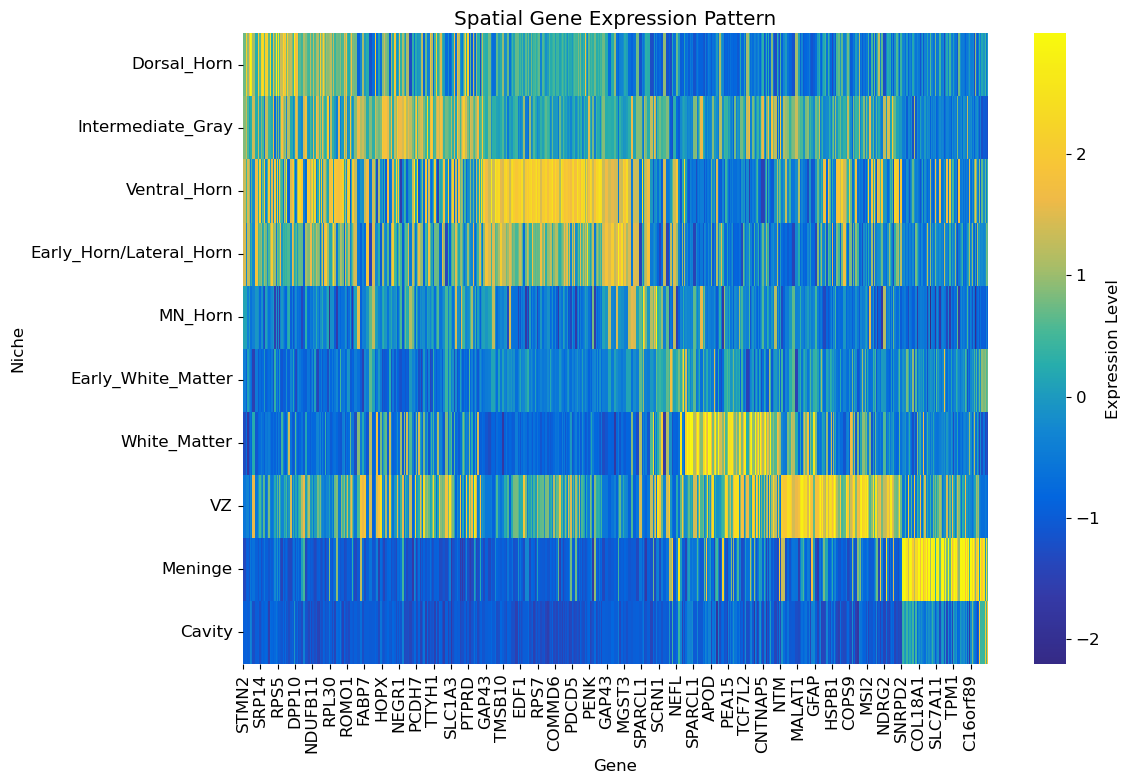

In [122]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import pandas as pd

# 1. 定义固定的 niche 顺序
niche_order = [
    "Dorsal_Horn",
    "Intermediate_Gray",
    "Ventral_Horn",
    "Early_Horn/Lateral_Horn",
    "MN_Horn",
    "Early_White_Matter",
    "White_Matter",
    "VZ",
    "Meninge",
    "Cavity"
]

top_genes_ordered = pd.DataFrame()  # 创建空DataFrame用于存储排序结果

for niche in niche_order:
    niche_genes = top_genes_per_niche[top_genes_per_niche['group'] == niche]
    top_genes_ordered = pd.concat([top_genes_ordered, niche_genes])
    
# 2. 定义固定的基因顺序（替换成你的实际基因列表）
gene_order = top_genes_ordered['names']

# 3. 提取表达矩阵（假设 adata 已经包含差异基因）
exp_matrix = adata[:, gene_order].X.toarray()  # 如果是稀疏矩阵
exp_df = pd.DataFrame(
    exp_matrix,
    columns=gene_order,
    index=adata.obs['niche']
)

# 4. 计算每个 niche 的平均表达（按固定顺序）
mean_exp_df = exp_df.groupby('niche').mean()
mean_exp_df = mean_exp_df.loc[niche_order]  # 按指定顺序排列 niche
mean_exp_df = mean_exp_df[gene_order]       # 按指定顺序排列基因
mean_exp_df = mean_exp_df.apply(zscore)

custom_colors = [
    "#352A86", "#343296", "#343AA7", "#2646BB", "#1156D0",
    "#0366DE", "#0A76D8", "#1286D2", "#1C99C0", "#27ADAC",
    "#46B897", "#78BB7E", "#A9BD67", "#CCBC57", "#EFBA47",
    "#F7C438", "#F6D12B", "#F6DF1F", "#F7EC16", "#F8FA0D"
]

# 2. 创建自定义色图
custom_cmap = LinearSegmentedColormap.from_list("custom_gradient", custom_colors, N=256)

# 5. 绘制热图（固定行列顺序）
plt.figure(figsize=(12, 8))
sns.heatmap(
    mean_exp_df,  # 转置：基因在行，niche在列
    cmap=custom_cmap,
    #linewidths=0.5,
    cbar_kws={"label": "Expression Level"},
    #xticklabels=True,
    #yticklabels=True,
)

plt.title("Spatial Gene Expression Pattern")
plt.xlabel("Gene")
plt.ylabel("Niche")

plt.savefig("spatial_niche_gene_pattern.pdf", 
           format='pdf', 
           dpi=300,
           bbox_inches='tight')  # bbox_inches确保所有内容被保存

plt.tight_layout()
plt.show()

In [107]:
mean_exp_df

names,STMN2,STMN2,STMN2,STMN2,STMN2,RBFOX1,RBFOX1,TMSB10,TMSB10,TMSB10,...,HBG1,HBG1,HBA2,HBA2,HBA2,TNNC2,ACTA1,LGALS1,LGALS1,DLK1
niche,,,,,,,,,,,,,,,,,,,,,
Dorsal_Horn,0.755427,0.755427,0.755427,0.755427,0.755427,2.190524,2.190524,0.961258,0.961258,0.961258,...,0.191168,0.191168,-0.035800,-0.035800,-0.035800,0.115515,0.436635,-0.573323,-0.573323,-0.001986
Intermediate_Gray,0.878357,0.878357,0.878357,0.878357,0.878357,1.299345,1.299345,0.564457,0.564457,0.564457,...,-1.221870,-1.221870,-1.003692,-1.003692,-1.003692,-1.080742,-1.075407,-1.044665,-1.044665,-1.245644
Ventral_Horn,1.326891,1.326891,1.326891,1.326891,1.326891,0.477143,0.477143,1.446268,1.446268,1.446268,...,0.670551,0.670551,-0.173122,-0.173122,-0.173122,1.041589,0.706477,-0.453192,-0.453192,0.476120
Early_Horn/Lateral_Horn,1.434085,1.434085,1.434085,1.434085,1.434085,-0.216493,-0.216493,1.277545,1.277545,1.277545,...,-0.209479,-0.209479,-0.309718,-0.309718,-0.309718,0.902595,-0.115548,0.794981,0.794981,0.668802
MN_Horn,0.139192,0.139192,0.139192,0.139192,0.139192,0.112879,0.112879,-0.379658,-0.379658,-0.379658,...,-0.952670,-0.952670,-0.895445,-0.895445,-0.895445,-1.091820,-0.998038,-0.365725,-0.365725,-0.898749
Early_White_Matter,-0.419444,-0.419444,-0.419444,-0.419444,-0.419444,-0.924863,-0.924863,0.091486,0.091486,0.091486,...,0.941030,0.941030,0.781252,0.781252,0.781252,0.529528,0.952545,0.574162,0.574162,0.760247
White_Matter,-1.287049,-1.287049,-1.287049,-1.287049,-1.287049,-0.721639,-0.721639,-1.726445,-1.726445,-1.726445,...,-1.227882,-1.227882,-0.629149,-0.629149,-0.629149,-1.462367,-1.386610,-1.124345,-1.124345,-1.384874
VZ,-0.539298,-0.539298,-0.539298,-0.539298,-0.539298,-0.369137,-0.369137,-0.350849,-0.350849,-0.350849,...,-0.664687,-0.664687,-0.697228,-0.697228,-0.697228,-0.670129,-0.492623,-0.610750,-0.610750,-0.819041
Meninge,-1.344197,-1.344197,-1.344197,-1.344197,-1.344197,-0.981012,-0.981012,-0.906701,-0.906701,-0.906701,...,2.003212,2.003212,2.525936,2.525936,2.525936,0.025160,-0.044755,2.327173,2.327173,0.585913
